<a href="https://colab.research.google.com/github/ashikjoel/Project-2-Real-Time-Industrial-Defect-Detection-System-Computer-Vision-/blob/week1/Real_Time_Industrial_Defect_Detection_System(week_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import userdata
api_key=userdata.get('kaggle')

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
Path to dataset files: /kaggle/input/neu-surface-defect-database


In [ ]:
!kaggle datasets download -d kaustubhdikshit/neu-surface-defect-database

Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:02<00:00, 9.81MB/s]



In [ ]:
!unzip neu-surface-defect-database.zip -d neu_dataset

Archive:  neu-surface-defect-database.zip
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_1.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_10.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_100.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_101.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_102.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_103.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_104.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_105.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_106.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_107.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_108.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_109.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_11.xml  
  inflating: neu_dataset/NEU-DET/train/annotations/crazing_110.xm

In [ ]:
import os

print(os.listdir("neu_dataset"))

['NEU-DET']


In [ ]:
import zipfile

zip_path = "/content/neu-surface-defect-database.zip"
extract_path = "/content/neu_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

dataset_path = "/content/neu_dataset"

print("Contents of dataset folder:\n")

for item in os.listdir(dataset_path):
    print(item)

Contents of dataset folder:

NEU-DET


In [ ]:
import os

dataset_path = "/content/neu_dataset/NEU-DET"

print("Contents of NEU-DET:\n")

for item in os.listdir(dataset_path):
    print(item)

Contents of NEU-DET:

validation
train


In [ ]:
import os

train_path = "/content/neu_dataset/NEU-DET/train"

print("Contents of train folder:\n")

for item in os.listdir(train_path):
    print(item)

Contents of train folder:

annotations
images


In [ ]:
import os

annotations_path = "/content/neu_dataset/NEU-DET/train/annotations"

files = os.listdir(annotations_path)

print("Number of annotation files:", len(files))
print("\nFirst 10 annotation files:")

for f in files[:10]:
    print(f)

Number of annotation files: 1439

First 10 annotation files:
pitted_surface_207.xml
inclusion_190.xml
inclusion_164.xml
pitted_surface_213.xml
patches_123.xml
scratches_57.xml
scratches_19.xml
inclusion_218.xml
crazing_158.xml
crazing_142.xml


# Load and display a sample XML annotation file to inspect dataset structure

In [ ]:
import os

xml_path = "/content/neu_dataset/NEU-DET/train/annotations"

sample_file = os.listdir(xml_path)[0]

with open(os.path.join(xml_path, sample_file), "r") as f:
    print(f.read())

<annotation>
	<folder>ps</folder>
	<filename>pitted_surface_207.jpg</filename>
	<source>
  		 <database>NEU-DET</database>
	</source>
	<size>
		<width>200</width>
		<height>200</height>
		<depth>1</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>pitted_surface</name>
		<pose>Unspecified</pose>
		<truncated>1</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>1</xmin>
			<ymin>12</ymin>
			<xmax>155</xmax>
			<ymax>200</ymax>
		</bndbox>
	</object>
	<object>
		<name>patches</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>161</xmin>
			<ymin>8</ymin>
			<xmax>199</xmax>
			<ymax>87</ymax>
		</bndbox>
	</object>
	<object>
		<name>patches</name>
		<pose>Unspecified</pose>
		<truncated>1</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>134</xmin>
			<ymin>136</ymin>
			<xmax>200</xmax>
			<ymax>200</ymax>
		</bndbox>
	</object>
</annotation>



#to check number of class in dataset

In [ ]:
import os
import xml.etree.ElementTree as ET

annotations_path = "/content/neu_dataset/NEU-DET/train/annotations"

classes = set()

for xml_file in os.listdir(annotations_path):
    tree = ET.parse(os.path.join(annotations_path, xml_file))
    root = tree.getroot()

    for obj in root.findall("object"):
        classes.add(obj.find("name").text)

print("Classes found:")
for cls in sorted(classes):
    print(cls)

Classes found:
crazing
inclusion
patches
pitted_surface
rolled-in_scale
scratches


# Convert Pascal VOC XML annotations into YOLO format (class_id, x_center, y_center, width, height)

In [ ]:
import xml.etree.ElementTree as ET

class_map = {
    "crazing": 0,
    "inclusion": 1,
    "patches": 2,
    "pitted_surface": 3,
    "rolled-in_scale": 4,
    "scratches": 5
}

xml_file = "/content/neu_dataset/NEU-DET/train/annotations/pitted_surface_207.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

img_width = int(root.find("size/width").text)
img_height = int(root.find("size/height").text)

print("YOLO Format Labels:\n")

for obj in root.findall("object"):
    class_name = obj.find("name").text
    class_id = class_map[class_name]

    bbox = obj.find("bndbox")

    xmin = float(bbox.find("xmin").text)
    ymin = float(bbox.find("ymin").text)
    xmax = float(bbox.find("xmax").text)
    ymax = float(bbox.find("ymax").text)

    x_center = ((xmin + xmax) / 2) / img_width
    y_center = ((ymin + ymax) / 2) / img_height
    width = (xmax - xmin) / img_width
    height = (ymax - ymin) / img_height

    print(
        class_id,
        round(x_center, 6),
        round(y_center, 6),
        round(width, 6),
        round(height, 6)
    )

YOLO Format Labels:

3 0.39 0.53 0.77 0.94
2 0.9 0.2375 0.19 0.395
2 0.835 0.84 0.33 0.32


In [ ]:
import os

train_images = "/content/neu_dataset/NEU-DET/train/images"
val_images = "/content/neu_dataset/NEU-DET/validation/images"

print("Train Images:", len(os.listdir(train_images)))
print("Validation Images:", len(os.listdir(val_images)))

Train Images: 6
Validation Images: 6


In [ ]:
import os

train_images = "/content/neu_dataset/NEU-DET/train/images"

for item in os.listdir(train_images):
    print(item)

rolled-in_scale
inclusion
pitted_surface
crazing
patches
scratches


#number of images in each catogory

In [ ]:
import os

train_images_path = "/content/neu_dataset/NEU-DET/train/images"

total_images = 0

for class_folder in os.listdir(train_images_path):
    class_path = os.path.join(train_images_path, class_folder)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        total_images += count
        print(f"{class_folder}: {count}")

print("\nTotal Train Images:", total_images)

rolled-in_scale: 240
inclusion: 240
pitted_surface: 240
crazing: 240
patches: 240
scratches: 240

Total Train Images: 1440


#checked images without annotation

In [ ]:
import os

images_root = "/content/neu_dataset/NEU-DET/train/images"
annotations_root = "/content/neu_dataset/NEU-DET/train/annotations"

image_names = set()

for class_folder in os.listdir(images_root):
    class_path = os.path.join(images_root, class_folder)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            image_names.add(os.path.splitext(img)[0])

xml_names = {
    os.path.splitext(f)[0]
    for f in os.listdir(annotations_root)
    if f.endswith(".xml")
}

print("Images without XML:")
print(image_names - xml_names)

print("\nXMLs without Images:")
print(xml_names - image_names)

Images without XML:
{'crazing_240'}

XMLs without Images:
set()


In [ ]:
import os

image_path = "/content/neu_dataset/NEU-DET/train/images/crazing/crazing_240.jpg"

print("Exists:", os.path.exists(image_path))

Exists: True


In [ ]:
import os

image_path = "/content/neu_dataset/NEU-DET/train/images/crazing/crazing_240.jpg"

os.remove(image_path)

print("Removed:", image_path)

Removed: /content/neu_dataset/NEU-DET/train/images/crazing/crazing_240.jpg


In [ ]:
import os

images_root = "/content/neu_dataset/NEU-DET/train/images"
annotations_root = "/content/neu_dataset/NEU-DET/train/annotations"

total_images = 0

for class_folder in os.listdir(images_root):
    class_path = os.path.join(images_root, class_folder)

    if os.path.isdir(class_path):
        total_images += len(os.listdir(class_path))

total_annotations = len([
    f for f in os.listdir(annotations_root)
    if f.endswith(".xml")
])

print("Total Images:", total_images)
print("Total Annotations:", total_annotations)

Total Images: 1439
Total Annotations: 1439


In [ ]:
import os

val_images_root = "/content/neu_dataset/NEU-DET/validation/images"
val_annotations_root = "/content/neu_dataset/NEU-DET/validation/annotations"

total_images = 0

for class_folder in os.listdir(val_images_root):
    class_path = os.path.join(val_images_root, class_folder)

    if os.path.isdir(class_path):
        total_images += len(os.listdir(class_path))

total_annotations = len([
    f for f in os.listdir(val_annotations_root)
    if f.endswith(".xml")
])

print("Validation Images:", total_images)
print("Validation Annotations:", total_annotations)

Validation Images: 360
Validation Annotations: 361


In [ ]:
import os

images_root = "/content/neu_dataset/NEU-DET/validation/images"
annotations_root = "/content/neu_dataset/NEU-DET/validation/annotations"

image_names = set()

for class_folder in os.listdir(images_root):
    class_path = os.path.join(images_root, class_folder)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            image_names.add(os.path.splitext(img)[0])

xml_names = {
    os.path.splitext(f)[0]
    for f in os.listdir(annotations_root)
    if f.endswith(".xml")
}

print("Images without XML:")
print(image_names - xml_names)

print("\nXMLs without Images:")
print(xml_names - image_names)

Images without XML:
set()

XMLs without Images:
{'crazing_240'}


In [ ]:
import xml.etree.ElementTree as ET

xml_file = "/content/neu_dataset/NEU-DET/validation/annotations/crazing_240.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

print("Filename:", root.find("filename").text)

Filename: crazing_240.jpg


In [ ]:
import os

xml_path = "/content/neu_dataset/NEU-DET/validation/annotations/crazing_240.xml"

os.remove(xml_path)

print("Removed:", xml_path)

Removed: /content/neu_dataset/NEU-DET/validation/annotations/crazing_240.xml


In [ ]:
import os

val_images_root = "/content/neu_dataset/NEU-DET/validation/images"
val_annotations_root = "/content/neu_dataset/NEU-DET/validation/annotations"

total_images = 0

for class_folder in os.listdir(val_images_root):
    class_path = os.path.join(val_images_root, class_folder)

    if os.path.isdir(class_path):
        total_images += len(os.listdir(class_path))

total_annotations = len([
    f for f in os.listdir(val_annotations_root)
    if f.endswith(".xml")
])

print("Validation Images:", total_images)
print("Validation Annotations:", total_annotations)

Validation Images: 360
Validation Annotations: 360


In [ ]:
import os

base_path = "/content/yolo_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("YOLO dataset structure created successfully!")

YOLO dataset structure created successfully!


In [ ]:
import os
import shutil

source_root = "/content/neu_dataset/NEU-DET/train/images"
destination = "/content/yolo_dataset/images/train"

count = 0

for class_folder in os.listdir(source_root):
    class_path = os.path.join(source_root, class_folder)

    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):

            src = os.path.join(class_path, image_file)
            dst = os.path.join(destination, image_file)

            shutil.copy2(src, dst)
            count += 1

print("Training images copied:", count)

Training images copied: 1439


In [ ]:
import os

train_images_path = "/content/yolo_dataset/images/train"

print("Images in YOLO train folder:", len(os.listdir(train_images_path)))

Images in YOLO train folder: 1439


In [ ]:
import os
import shutil

source_root = "/content/neu_dataset/NEU-DET/validation/images"
destination = "/content/yolo_dataset/images/val"

count = 0

for class_folder in os.listdir(source_root):
    class_path = os.path.join(source_root, class_folder)

    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):

            src = os.path.join(class_path, image_file)
            dst = os.path.join(destination, image_file)

            shutil.copy2(src, dst)
            count += 1

print("Validation images copied:", count)

Validation images copied: 360


In [ ]:
import os

val_images_path = "/content/yolo_dataset/images/val"

print("Images in YOLO validation folder:", len(os.listdir(val_images_path)))

Images in YOLO validation folder: 360


In [ ]:
import os
import xml.etree.ElementTree as ET

class_map = {
    "crazing": 0,
    "inclusion": 1,
    "patches": 2,
    "pitted_surface": 3,
    "rolled-in_scale": 4,
    "scratches": 5
}

xml_file = "/content/neu_dataset/NEU-DET/train/annotations/pitted_surface_207.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

img_width = int(root.find("size/width").text)
img_height = int(root.find("size/height").text)

output_file = "/content/yolo_dataset/labels/train/pitted_surface_207.txt"

with open(output_file, "w") as f:

    for obj in root.findall("object"):

        class_name = obj.find("name").text
        class_id = class_map[class_name]

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        f.write(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{width:.6f} "
            f"{height:.6f}\n"
        )

print("YOLO label file created!")

YOLO label file created!


In [ ]:
label_file = "/content/yolo_dataset/labels/train/pitted_surface_207.txt"

with open(label_file, "r") as f:
    print(f.read())

3 0.390000 0.530000 0.770000 0.940000
2 0.900000 0.237500 0.190000 0.395000
2 0.835000 0.840000 0.330000 0.320000



In [ ]:
import os
import xml.etree.ElementTree as ET

class_map = {
    "crazing": 0,
    "inclusion": 1,
    "patches": 2,
    "pitted_surface": 3,
    "rolled-in_scale": 4,
    "scratches": 5
}

xml_folder = "/content/neu_dataset/NEU-DET/train/annotations"
output_folder = "/content/yolo_dataset/labels/train"

count = 0

for xml_name in os.listdir(xml_folder):

    if not xml_name.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(xml_folder, xml_name))
    root = tree.getroot()

    img_width = int(root.find("size/width").text)
    img_height = int(root.find("size/height").text)

    txt_name = xml_name.replace(".xml", ".txt")
    txt_path = os.path.join(output_folder, txt_name)

    with open(txt_path, "w") as f:

        for obj in root.findall("object"):

            class_name = obj.find("name").text
            class_id = class_map[class_name]

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            x_center = ((xmin + xmax) / 2) / img_width
            y_center = ((ymin + ymax) / 2) / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height

            f.write(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}\n"
            )

    count += 1

print("Training labels converted:", count)

Training labels converted: 1439


In [ ]:
import os

train_labels_path = "/content/yolo_dataset/labels/train"

print("YOLO Train Labels:", len(os.listdir(train_labels_path)))

YOLO Train Labels: 1439


In [ ]:
import os
import xml.etree.ElementTree as ET

class_map = {
    "crazing": 0,
    "inclusion": 1,
    "patches": 2,
    "pitted_surface": 3,
    "rolled-in_scale": 4,
    "scratches": 5
}

xml_folder = "/content/neu_dataset/NEU-DET/validation/annotations"
output_folder = "/content/yolo_dataset/labels/val"

count = 0

for xml_name in os.listdir(xml_folder):

    if not xml_name.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(xml_folder, xml_name))
    root = tree.getroot()

    img_width = int(root.find("size/width").text)
    img_height = int(root.find("size/height").text)

    txt_name = xml_name.replace(".xml", ".txt")
    txt_path = os.path.join(output_folder, txt_name)

    with open(txt_path, "w") as f:

        for obj in root.findall("object"):

            class_name = obj.find("name").text
            class_id = class_map[class_name]

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            x_center = ((xmin + xmax) / 2) / img_width
            y_center = ((ymin + ymax) / 2) / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height

            f.write(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}\n"
            )

    count += 1

print("Validation labels converted:", count)

Validation labels converted: 360


In [ ]:
import os

val_labels_path = "/content/yolo_dataset/labels/val"

print("YOLO Validation Labels:", len(os.listdir(val_labels_path)))

YOLO Validation Labels: 360


In [ ]:
data_yaml = """
path: /content/yolo_dataset

train: images/train
val: images/val

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created successfully!")

data.yaml created successfully!


# Visualize YOLO annotations by drawing bounding boxes and class labels on a random training image

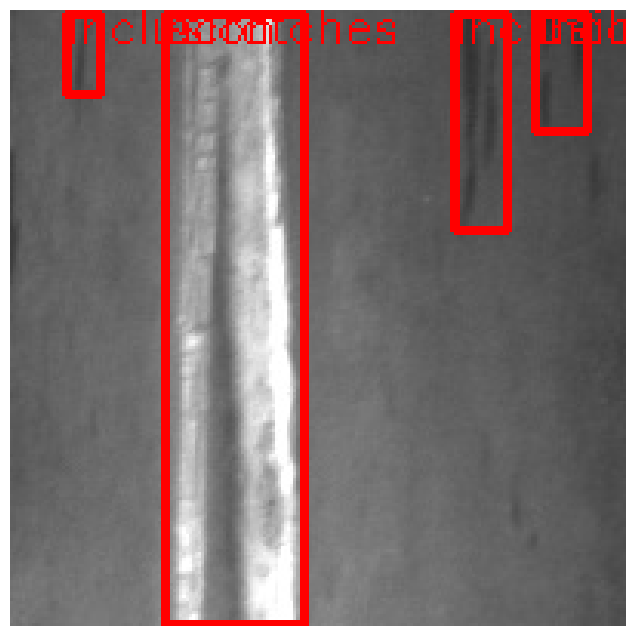

Image: scratches_111.jpg


In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# Class names
classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

image_dir = "/content/yolo_dataset/images/train"
label_dir = "/content/yolo_dataset/labels/train"

# Pick a random image
image_file = random.choice(os.listdir(image_dir))

image_path = os.path.join(image_dir, image_file)
label_path = os.path.join(
    label_dir,
    image_file.replace(".jpg", ".txt")
)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

with open(label_path, "r") as f:
    labels = f.readlines()

for label in labels:

    class_id, x_center, y_center, bw, bh = map(float, label.split())

    x_center *= w
    y_center *= h
    bw *= w
    bh *= h

    xmin = int(x_center - bw / 2)
    ymin = int(y_center - bh / 2)
    xmax = int(x_center + bw / 2)
    ymax = int(y_center + bh / 2)

    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    cv2.putText(
        img,
        classes[int(class_id)],
        (xmin, max(ymin - 5, 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

print("Image:", image_file)

# Visualize YOLO bounding box annotations on multiple random training images

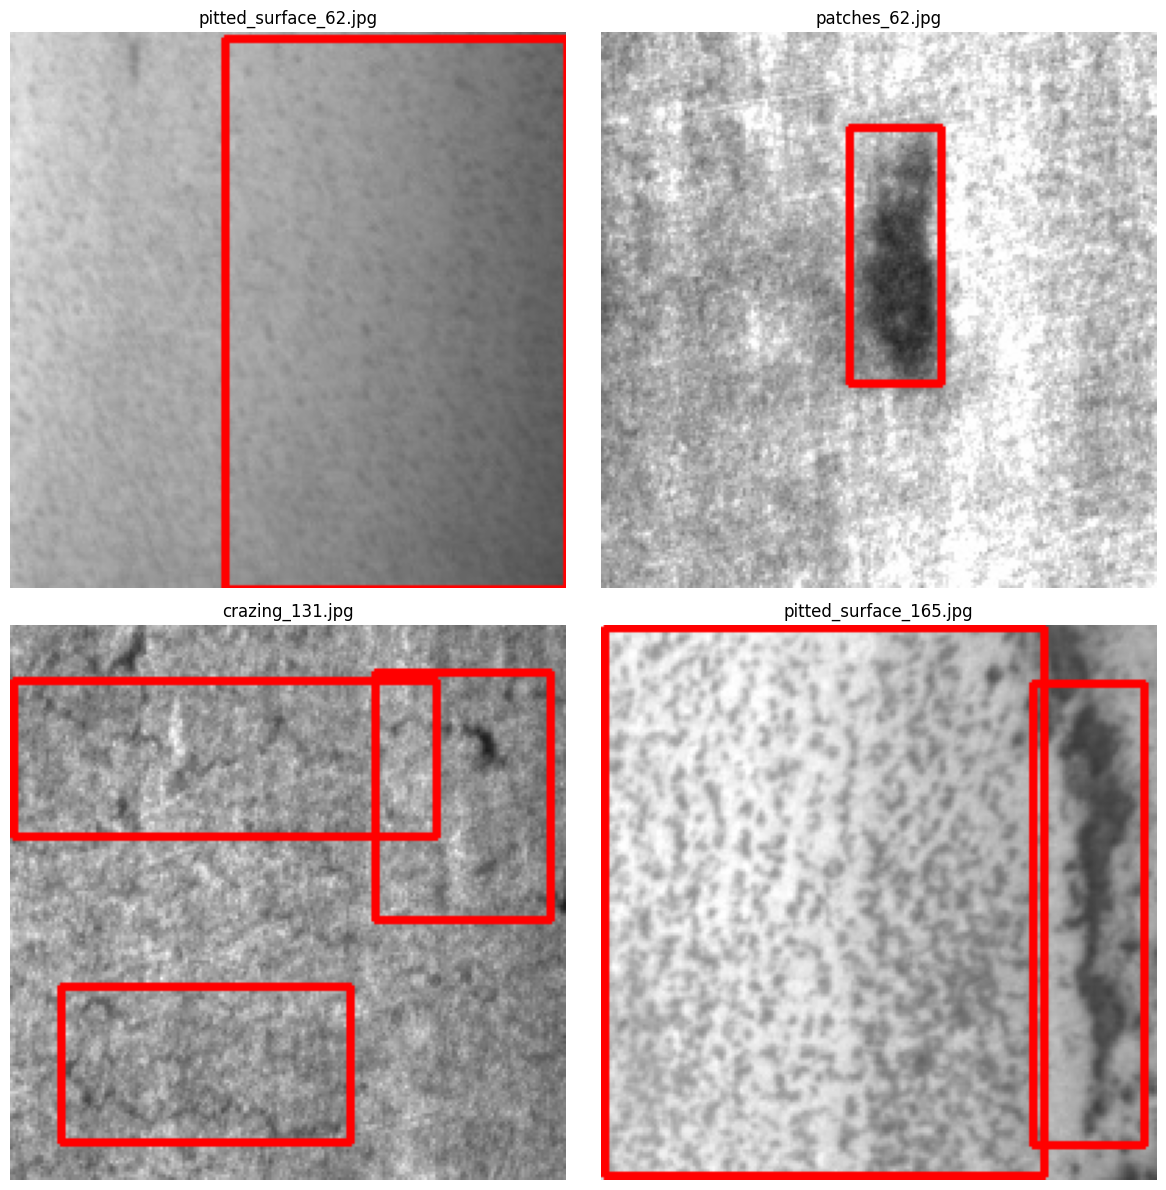

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

image_dir = "/content/yolo_dataset/images/train"
label_dir = "/content/yolo_dataset/labels/train"

samples = random.sample(os.listdir(image_dir), 4)

plt.figure(figsize=(12,12))

for idx, image_file in enumerate(samples):

    image_path = os.path.join(image_dir, image_file)
    label_path = os.path.join(
        label_dir,
        image_file.replace(".jpg", ".txt")
    )

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    with open(label_path, "r") as f:
        labels = f.readlines()

    for label in labels:

        class_id, x_center, y_center, bw, bh = map(float, label.split())

        x_center *= w
        y_center *= h
        bw *= w
        bh *= h

        xmin = int(x_center - bw/2)
        ymin = int(y_center - bh/2)
        xmax = int(x_center + bw/2)
        ymax = int(y_center + bh/2)

        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255,0,0), 2)

    plt.subplot(2,2,idx+1)
    plt.imshow(img)
    plt.title(image_file)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Load and inspect the YOLO dataset configuration file (data.yaml)

In [ ]:
import yaml

with open("/content/yolo_dataset/data.yaml") as f:
    data = yaml.safe_load(f)

print(data)

{'path': '/content/yolo_dataset', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}}


In [ ]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/Industrial_Defect_Detection"

In [ ]:
!cp -r /content/yolo_dataset "/content/drive/MyDrive/Industrial_Defect_Detection/"

In [ ]:
!ls "/content/drive/MyDrive/Industrial_Defect_Detection"

yolo_dataset
